# Klasifikasi Pembelian — EDA, Baseline, Model & Evaluasi (Tugas 1, bagian Genda)

**Tujuan:** memahami `data/training/klasifikasi_pembelian.csv` secara menyeluruh
sebelum membangun model — struktur grup, kualitas data, pola NaN, distribusi
fitur, dan hubungan fitur terhadap target — supaya keputusan pemodelan
(baseline, penanganan NaN, feature yang layak) didasari data, bukan tebakan.
Lanjutan dari EDA: bangun & bandingkan 5 baseline, pilih model, evaluasi,
analisis, simpan artefak.

**Konteks wajib diingat (lihat `genda.md` & `data/training/KAMUS_DATA.md`):**
- Seluruh data **SINTETIS** (dibangkitkan `src/generate.py`, seed 42). Model
  belajar aturan buatan kita, bukan perilaku pembeli nyata — jangan klaim
  angka di sini sebagai performa produksi.
- Kolom pengenal **BUKAN fitur**: `grup_id, split, waktu, transaksi_id,
  kolektor_id, karya_id, seniman_id`.
- `kolektor_label_asli` (dibaca terpisah, bukan kolom di file ini) **dilarang**
  jadi fitur — hanya untuk analisis kesalahan model nanti.
- Evaluasi per **grup** (ranking), bukan akurasi baris biasa — 1 grup = 1
  positif (`dibeli=1`) + 4 negatif (`dibeli=0`) yang tersedia saat itu.


## 0. Muat data

`waktu` di-parse sebagai datetime dari awal supaya semua pengecekan urutan
waktu (split, riwayat "sebelum t") bisa langsung memakai operator tanggal.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

df = pd.read_csv("../data/training/klasifikasi_pembelian.csv", parse_dates=["waktu"])

ID_COLS = ["grup_id", "split", "waktu", "transaksi_id", "kolektor_id", "karya_id", "seniman_id"]
TARGET = "dibeli"
FITUR_KATEGORIKAL = ["karya_gaya", "seniman_level_reputasi"]
FITUR_NUMERIK = [c for c in df.columns if c not in ID_COLS + [TARGET] + FITUR_KATEGORIKAL]
FITUR = FITUR_NUMERIK + FITUR_KATEGORIKAL

print("Shape:", df.shape)
df.dtypes


Shape: (7000, 42)


grup_id                                            int64
split                                             object
waktu                                datetime64[ns, UTC]
transaksi_id                                      object
kolektor_id                                       object
karya_id                                          object
seniman_id                                        object
dibeli                                             int64
kolektor_n_beli_sebelumnya                         int64
kolektor_hari_sejak_bergabung                    float64
kolektor_hari_sejak_beli_terakhir                float64
kolektor_n_beli_90hari                             int64
kolektor_harga_rata2_idr                         float64
kolektor_harga_median_idr                        float64
kolektor_harga_min_idr                           float64
kolektor_harga_maks_idr                          float64
kolektor_harga_std_log                           float64
kolektor_n_gaya_unik           

## 1. Struktur grup & sanity check dasar

`grup_id` = 1 kejadian pembelian nyata (1 baris `dibeli=1`) + beberapa karya
lain yang tersedia saat itu tapi tidak dibeli (`dibeli=0`). Sebelum apa pun
lain, pastikan struktur ini benar: tiap grup harus persis 5 baris dengan
persis 1 baris positif, dan tidak boleh ada grup yang "terpecah" ke lebih
dari satu `split`.


In [2]:
n_baris = len(df)
n_grup = df["grup_id"].nunique()
ukuran_grup = df.groupby("grup_id").size()
n_positif_per_grup = df.groupby("grup_id")[TARGET].sum()
split_per_grup = df.groupby("grup_id")["split"].nunique()

print(f"Total baris           : {n_baris}")
print(f"Total grup unik       : {n_grup}")
print(f"Rata-rata baris/grup  : {ukuran_grup.mean():.2f}")
print(f"Grup dgn ukuran != 5  : {(ukuran_grup != 5).sum()}")
print(f"Grup dgn positif != 1 : {(n_positif_per_grup != 1).sum()}")
print(f"Grup yg split-nya terpecah (>1 nilai split) : {(split_per_grup != 1).sum()}")
print(f"Total dibeli=1 : {(df[TARGET] == 1).sum()}  | dibeli=0 : {(df[TARGET] == 0).sum()}")


Total baris           : 7000
Total grup unik       : 1400
Rata-rata baris/grup  : 5.00
Grup dgn ukuran != 5  : 0
Grup dgn positif != 1 : 0
Grup yg split-nya terpecah (>1 nilai split) : 0
Total dibeli=1 : 1400  | dibeli=0 : 5600


**Interpretasi:** kalau semua angka "grup dgn ..." di atas menunjukkan 0,
berarti struktur grup bersih — setiap grup benar-benar berisi 1 kejadian beli
nyata + 4 kandidat negatif, tidak ada yang bocor lintas grup/split. Ini
prasyarat mutlak sebelum evaluasi ranking (HitRate@K, NDCG@K) bisa dipercaya.

## 2. Urutan waktu antar split

`split` dibagi berdasarkan **waktu pembelian**, bukan acak — kalau acak,
fitur riwayat "sebelum t" bisa memakai kejadian yang sebenarnya terjadi
setelah t di baris lain (kebocoran). Cek rentang waktu tiap split tidak
boleh saling tumpang tindih: `train` harus seluruhnya sebelum `val`, `val`
sebelum `test`.


In [3]:
rentang = df.drop_duplicates("grup_id").groupby("split")["waktu"].agg(["min", "max", "count"])
rentang = rentang.reindex(["train", "val", "test"])
rentang["persen_grup"] = (rentang["count"] / n_grup * 100).round(1)
print(rentang)

urut_benar = (
    rentang.loc["train", "max"] <= rentang.loc["val", "min"]
    and rentang.loc["val", "max"] <= rentang.loc["test", "min"]
)
print(f"\nUrutan waktu train -> val -> test tidak tumpang tindih: {urut_benar}")


                            min                       max  count  persen_grup
split                                                                        
train 2024-11-22 06:38:09+00:00 2026-07-03 06:10:55+00:00    980         70.0
val   2026-07-04 10:43:12+00:00 2026-08-17 22:46:39+00:00    210         15.0
test  2026-08-18 00:58:11+00:00 2026-09-30 23:50:28+00:00    210         15.0

Urutan waktu train -> val -> test tidak tumpang tindih: True


**Interpretasi:** proporsi `train`/`val`/`test` harus mendekati 70%/15%/15%
(sesuai desain di `KAMUS_DATA.md`), dan `urut_benar` harus `True`. Kalau ini
valid, pembagian waktunya sudah benar dan aman dipakai langsung tanpa
split ulang.

## 3. Distribusi target (`dibeli`)

Ini BUKAN dataset imbalanced yang perlu di-resampling — rasio 1:4 memang
desain evaluasi grup (1 positif + 4 negatif per grup), bukan refleksi
proporsi asli "beli vs tidak beli" di dunia nyata. Resampling di sini justru
merusak struktur grup yang dibutuhkan evaluasi ranking.


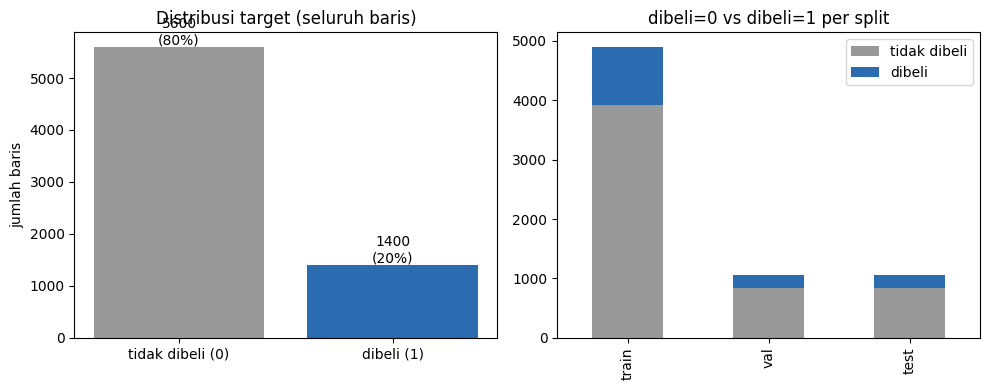

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

hitung = df[TARGET].value_counts().sort_index()
ax[0].bar(["tidak dibeli (0)", "dibeli (1)"], hitung.values, color=["#999999", "#2b6cb0"])
for i, v in enumerate(hitung.values):
    ax[0].text(i, v + 50, f"{v}\n({v/n_baris*100:.0f}%)", ha="center")
ax[0].set_title("Distribusi target (seluruh baris)")
ax[0].set_ylabel("jumlah baris")

per_split = df.groupby(["split", TARGET]).size().unstack()
per_split = per_split.reindex(["train", "val", "test"])
per_split.plot(kind="bar", stacked=True, ax=ax[1], color=["#999999", "#2b6cb0"])
ax[1].set_title("dibeli=0 vs dibeli=1 per split")
ax[1].set_xlabel("")
ax[1].legend(["tidak dibeli", "dibeli"])

plt.tight_layout()
plt.show()


**Interpretasi:** proporsi 80%/20% ini konsisten di semua split (train/val/
test) — tanda baik, berarti karakteristik grup tidak berubah drastis antar
periode waktu. Baseline tebak-acak untuk HitRate@1 = 1/5 = 0,20 (sudah
dikonfirmasi juga oleh `scripts/cek_sinyal_data.py`).

## 4. Pola *missing value* (NaN) — dan kenapa NaN di sini BERMAKNA

`KAMUS_DATA.md` menegaskan: NaN pada fitur riwayat kolektor/seniman berarti
"belum ada riwayat" (mis. pembelian pertama kolektor, atau seniman belum
pernah terjual dalam periode terkait) — **bukan** data yang hilang/error.
Men-drop baris ini akan membuang justru kasus penting (pembeli baru), dan
mengisi dengan 0 secara naif bisa menyesatkan model (0 kejadian != "harga
rata-rata 0").


Kolom dengan NaN (% dari seluruh baris):
transaksi_id                         80.0
kolektor_hari_sejak_beli_terakhir    14.3
kolektor_harga_rata2_idr             14.3
kolektor_harga_median_idr            14.3
kolektor_harga_min_idr               14.3
kolektor_harga_maks_idr              14.3
kolektor_harga_std_log               14.3
kolektor_porsi_gaya_teratas          14.3
match_porsi_gaya_ini                 14.3
match_rasio_harga_vs_rata2           14.3
match_selisih_log_harga_vs_median    14.3
match_harga_dalam_rentang            14.3
seniman_pertumbuhan_harga             8.7
seniman_harga_rata2_90hari_idr        3.4
gaya_porsi_penjualan_30hari           0.1
dtype: float64


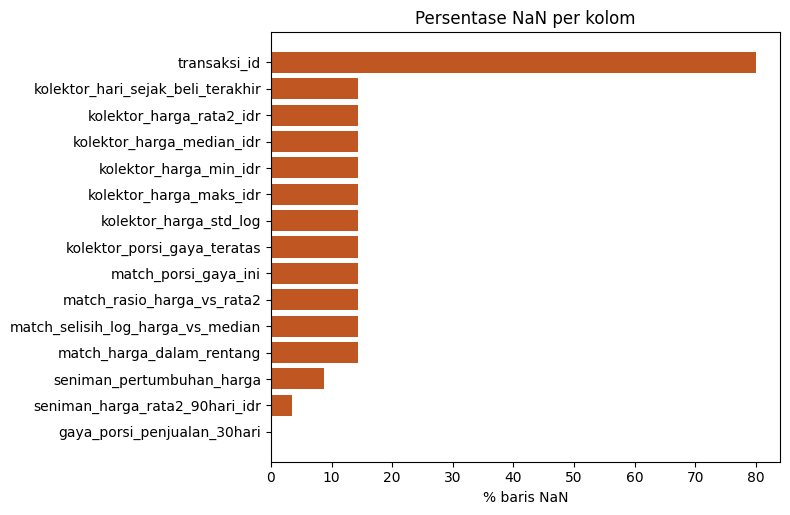

In [5]:
persen_nan = df.isna().mean().mul(100).round(1)
persen_nan = persen_nan[persen_nan > 0].sort_values(ascending=False)
print("Kolom dengan NaN (% dari seluruh baris):")
print(persen_nan)

fig, ax = plt.subplots(figsize=(8, max(3, len(persen_nan) * 0.35)))
ax.barh(persen_nan.index[::-1], persen_nan.values[::-1], color="#c05621")
ax.set_xlabel("% baris NaN")
ax.set_title("Persentase NaN per kolom")
plt.tight_layout()
plt.show()


Sekarang buktikan NaN itu memang berkorelasi dengan "belum ada riwayat",
bukan acak — bandingkan baris pembelian pertama kolektor
(`kolektor_n_beli_sebelumnya == 0`) vs yang bukan.


In [6]:
pembelian_pertama = df["kolektor_n_beli_sebelumnya"] == 0
kolom_riwayat_kolektor = [
    "kolektor_harga_rata2_idr", "kolektor_harga_median_idr",
    "kolektor_harga_min_idr", "kolektor_harga_maks_idr",
    "kolektor_porsi_gaya_teratas", "kolektor_hari_sejak_beli_terakhir",
]
print("% NaN kolom riwayat kolektor, dipecah per status 'pembelian pertama?':\n")
print(df.groupby(pembelian_pertama)[kolom_riwayat_kolektor].apply(lambda g: g.isna().mean().mul(100).round(1)))

# fitur seniman yg bisa NaN kalau seniman belum pernah terjual di periode terkait
print("\n% NaN fitur seniman (independen dari status kolektor):")
print(df[["seniman_harga_rata2_90hari_idr", "seniman_pertumbuhan_harga"]].isna().mean().mul(100).round(1))


% NaN kolom riwayat kolektor, dipecah per status 'pembelian pertama?':

                            kolektor_harga_rata2_idr  kolektor_harga_median_idr  kolektor_harga_min_idr  kolektor_harga_maks_idr  \
kolektor_n_beli_sebelumnya                                                                                                         
False                                            0.0                        0.0                     0.0                      0.0   
True                                           100.0                      100.0                   100.0                    100.0   

                            kolektor_porsi_gaya_teratas  kolektor_hari_sejak_beli_terakhir  
kolektor_n_beli_sebelumnya                                                                  
False                                               0.0                                0.0  
True                                              100.0                              100.0  

% NaN fitur seniman (indep

**Interpretasi:** kalau baris "pembelian pertama" nyaris 100% NaN di semua
kolom riwayat kolektor (sementara baris lain nyaris 0% NaN), ini mengonfirmasi
NaN memang penanda struktural "belum ada riwayat" — konsisten dengan
`KAMUS_DATA.md`. **Implikasi pemodelan:** pakai model yang bisa menangani NaN
langsung (`HistGradientBoostingClassifier` mendukung ini native) ATAU
imputasi + kolom indikator terpisah (`*_is_na`) — JANGAN drop baris/kolom
NaN begitu saja, itu akan membuang sinyal "kolektor baru" yang justru
informatif.

## 5. Distribusi fitur numerik

`describe()` dulu untuk gambaran skala/rentang tiap fitur, baru divisualkan
yang paling relevan (harga-harga cenderung *right-skewed* seperti lazimnya
data harga, dan beberapa match_* sudah berbentuk rasio 0-1).


In [7]:
df[FITUR_NUMERIK].describe().T


,count,mean,std,min,25%,50%,75%,max
kolektor_n_beli_sebelumnya,7000.0,4.772857e+00,5.206945e+00,0.000000e+00,1.000000e+00,3.000000e+00,6.000000e+00,3.600000e+01
kolektor_hari_sejak_bergabung,7000.0,2.546129e+02,1.541546e+02,1.475100e+00,1.383894e+02,2.257436e+02,3.562862e+02,6.869354e+02
kolektor_hari_sejak_beli_terakhir,6000.0,4.727613e+01,5.876894e+01,9.630000e-02,8.879725e+00,2.448905e+01,6.342925e+01,4.224984e+02
kolektor_n_beli_90hari,7000.0,2.355714e+00,3.307896e+00,0.000000e+00,0.000000e+00,1.000000e+00,3.000000e+00,2.400000e+01
kolektor_harga_rata2_idr,6000.0,5.465925e+07,5.293945e+07,1.530000e+06,2.171750e+07,4.328750e+07,6.722708e+07,5.760000e+08
kolektor_harga_median_idr,6000.0,4.877237e+07,4.984014e+07,1.530000e+06,1.798750e+07,3.515000e+07,5.815000e+07,5.760000e+08
kolektor_harga_min_idr,6000.0,2.878563e+07,3.952244e+07,1.530000e+06,7.232500e+06,1.450000e+07,2.800000e+07,3.370000e+08
kolektor_harga_maks_idr,6000.0,1.008427e+08,1.077441e+08,1.530000e+06,3.250000e+07,7.800000e+07,1.467500e+08,9.180000e+08
kolektor_harga_std_log,6000.0,4.814427e-01,3.411832e-01,0.000000e+00,1.978000e-01,5.035500e-01,7.219000e-01,2.374800e+00
kolektor_n_gaya_unik,7000.0,2.527857e+00,1.872282e+00,0.000000e+00,1.000000e+00,2.000000e+00,4.000000e+00,8.000000e+00


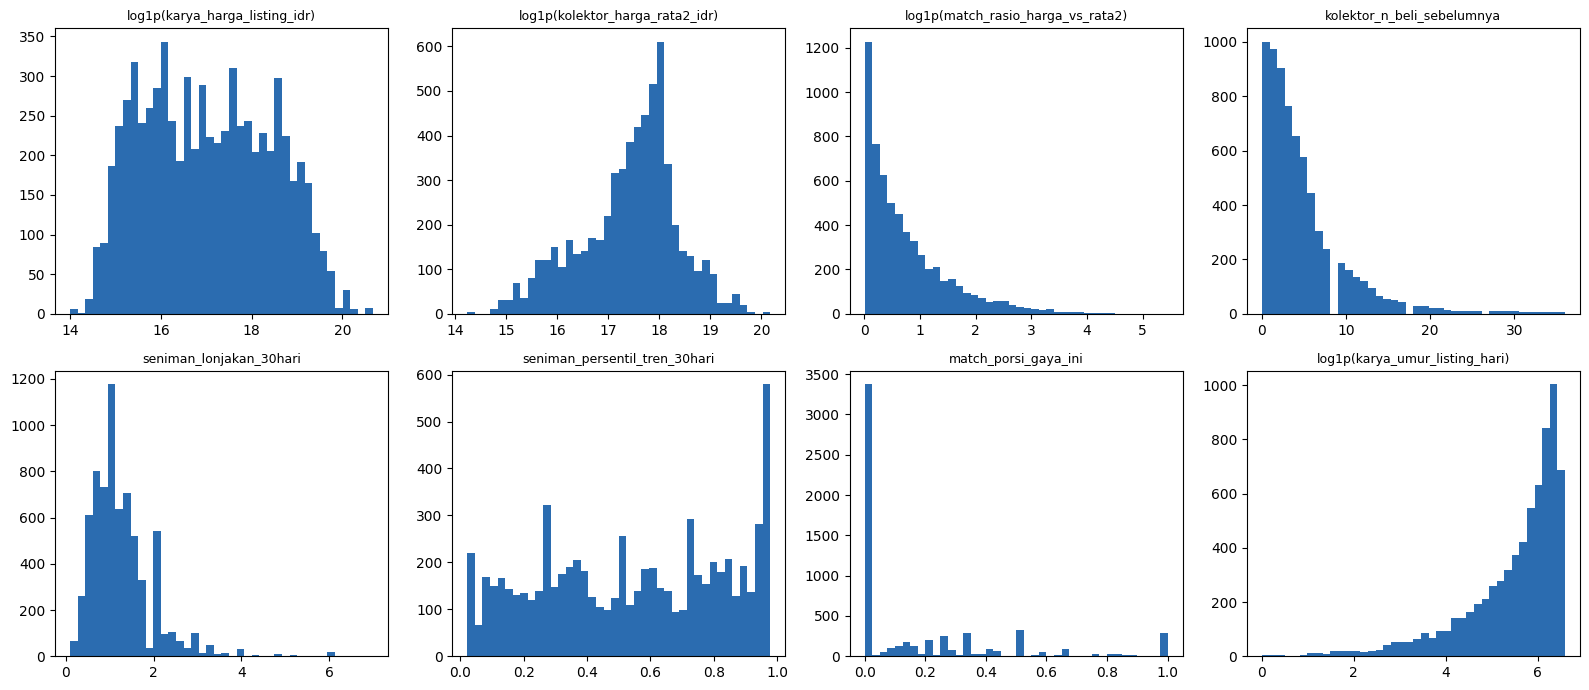

In [8]:
fitur_tampil = [
    "karya_harga_listing_idr", "kolektor_harga_rata2_idr",
    "match_rasio_harga_vs_rata2", "kolektor_n_beli_sebelumnya",
    "seniman_lonjakan_30hari", "seniman_persentil_tren_30hari",
    "match_porsi_gaya_ini", "karya_umur_listing_hari",
]
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, kol in zip(axes.flat, fitur_tampil):
    data = df[kol].dropna()
    # kolom harga/skewed -> log1p biar histogram lebih terbaca
    if "harga" in kol or kol == "karya_umur_listing_hari":
        ax.hist(np.log1p(data), bins=40, color="#2b6cb0")
        ax.set_title(f"log1p({kol})", fontsize=9)
    else:
        ax.hist(data, bins=40, color="#2b6cb0")
        ax.set_title(kol, fontsize=9)
plt.tight_layout()
plt.show()


**Interpretasi:** fitur bertipe harga (`*_idr`) dan `karya_umur_listing_hari`
terkonfirmasi *right-skewed* — wajar untuk data harga/durasi, dan ini alasan
dataset sudah menyediakan versi log-nya (`karya_log_harga`) untuk langsung
dipakai di model linear nanti. Fitur rasio seperti `match_porsi_gaya_ini`
dan `seniman_persentil_tren_30hari` sudah berskala 0-1, tidak perlu
transformasi tambahan.

## 6. Distribusi fitur kategorikal

Dua fitur kategorikal: `karya_gaya` (11 aliran, warisan dari 11 kelas model
Visual Search v1) dan `seniman_level_reputasi` (pemula/menengah/mapan).


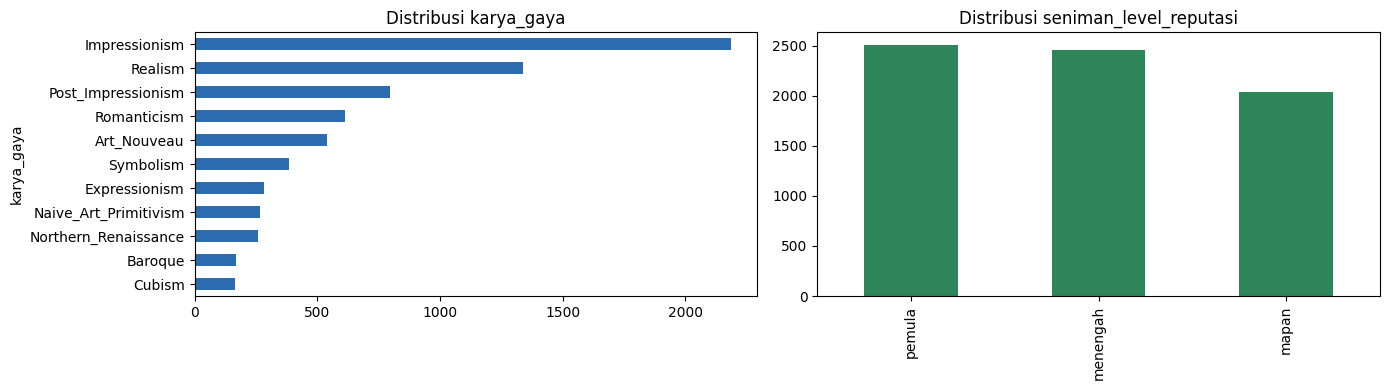

karya_gaya
Impressionism            2184
Realism                  1340
Post_Impressionism        798
Romanticism               614
Art_Nouveau               540
Symbolism                 386
Expressionism             282
Naive_Art_Primitivism     268
Northern_Renaissance      257
Baroque                   168
Cubism                    163
Name: count, dtype: int64

seniman_level_reputasi
pemula      2509
menengah    2457
mapan       2034
Name: count, dtype: int64


In [9]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

df["karya_gaya"].value_counts().plot(kind="barh", ax=ax[0], color="#2b6cb0")
ax[0].set_title("Distribusi karya_gaya")
ax[0].invert_yaxis()

urutan_reputasi = ["pemula", "menengah", "mapan"]
df["seniman_level_reputasi"].value_counts().reindex(urutan_reputasi).plot(
    kind="bar", ax=ax[1], color="#2f855a"
)
ax[1].set_title("Distribusi seniman_level_reputasi")
ax[1].set_xlabel("")

plt.tight_layout()
plt.show()

print(df["karya_gaya"].value_counts())
print()
print(df["seniman_level_reputasi"].value_counts())


**Interpretasi:** kalau salah satu kategori mendominasi sangat ekstrem (mis.
>90% baris), model bisa kesulitan belajar kategori minoritas — perlu dicatat
di `LAPORAN_MODEL.md` sebagai keterbatasan. `seniman_level_reputasi` dan
`karya_gaya` harus di-encode sebagai kategorikal (bukan numerik biasa) saat
training — lihat aturan #3 di `genda.md`.

## 7. Korelasi antar fitur numerik

Fitur-fitur harga (`kolektor_harga_rata2_idr`, `_median_idr`, `_min_idr`,
`_maks_idr`) kemungkinan besar sangat berkorelasi satu sama lain (semuanya
menyimpulkan "sebesar apa kolektor ini belanja") — penting diketahui kalau
nanti mau pakai model linear (multicollinearity bikin koefisien tidak
stabil), meski tidak masalah untuk model berbasis pohon seperti GBM.


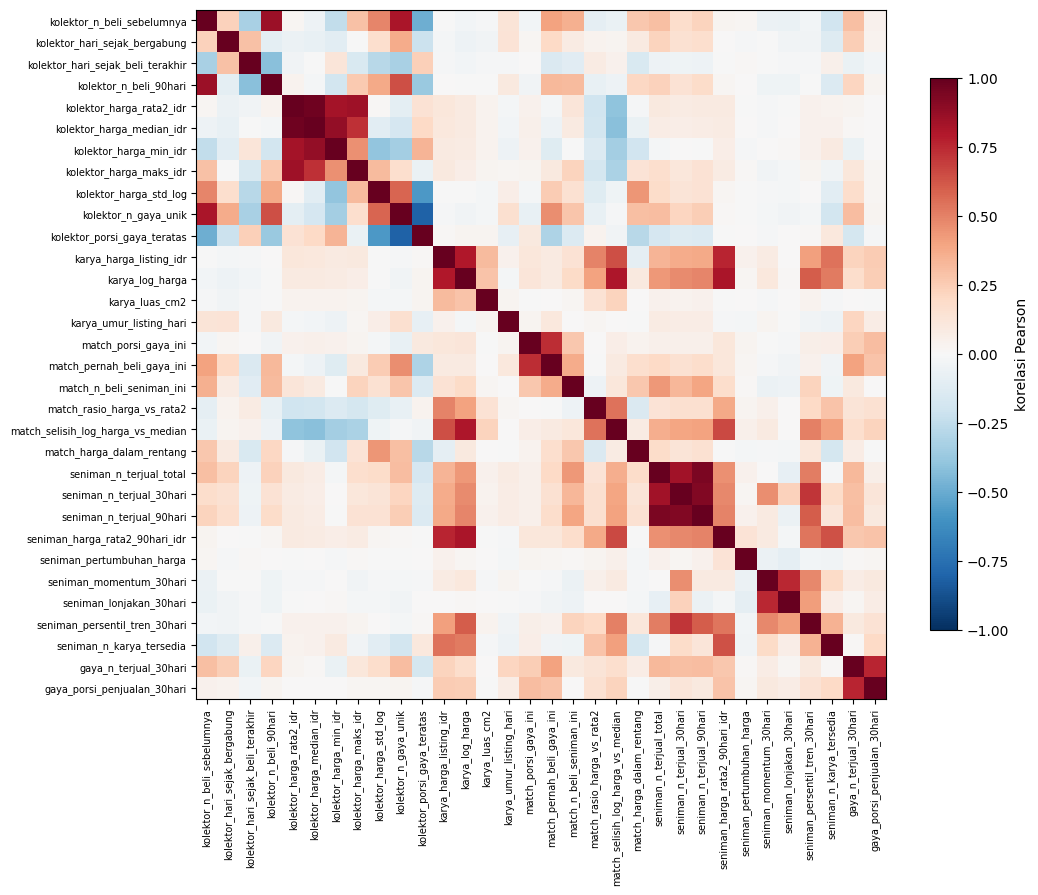

Pasangan fitur dgn |korelasi| > 0.8:
                   fitur_a                           fitur_b  korelasi
  kolektor_harga_rata2_idr         kolektor_harga_median_idr  0.971948
   seniman_n_terjual_total          seniman_n_terjual_90hari  0.941833
  seniman_n_terjual_30hari          seniman_n_terjual_90hari  0.924934
 kolektor_harga_median_idr            kolektor_harga_min_idr  0.878307
kolektor_n_beli_sebelumnya            kolektor_n_beli_90hari  0.856945
  kolektor_harga_rata2_idr           kolektor_harga_maks_idr  0.844489
   seniman_n_terjual_total          seniman_n_terjual_30hari  0.839547
  kolektor_harga_rata2_idr            kolektor_harga_min_idr  0.830757
kolektor_n_beli_sebelumnya              kolektor_n_gaya_unik  0.818590
           karya_log_harga    seniman_harga_rata2_90hari_idr  0.813809
      kolektor_n_gaya_unik       kolektor_porsi_gaya_teratas -0.808604
           karya_log_harga match_selisih_log_harga_vs_median  0.804691
   karya_harga_listing_idr              

In [10]:
corr = df[FITUR_NUMERIK].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns, fontsize=7)
fig.colorbar(im, ax=ax, shrink=0.8, label="korelasi Pearson")
plt.tight_layout()
plt.show()

# Pasangan dgn korelasi absolut tinggi (>0.8), selain diagonal
pasangan = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .rename("korelasi")
    .reset_index()
)
pasangan.columns = ["fitur_a", "fitur_b", "korelasi"]
tinggi = pasangan[pasangan["korelasi"].abs() > 0.8].sort_values("korelasi", key=abs, ascending=False)
print("Pasangan fitur dgn |korelasi| > 0.8:")
print(tinggi.to_string(index=False))


**Interpretasi:** pasangan-pasangan harga kolektor (rata2/median/min/maks)
kemungkinan muncul di daftar korelasi tinggi — ini wajar secara matematis
(semua turunan dari riwayat harga yang sama), bukan bug data. **Implikasi:**
kalau nanti mencoba Logistic Regression sebagai baseline (sesuai `genda.md`),
pertimbangkan regularisasi (L2) atau buang beberapa kolom yang redundan;
untuk `HistGradientBoostingClassifier` hal ini tidak masalah.

## 8. Hubungan fitur terhadap target (`dibeli`)

Bagian paling relevan untuk modeling: fitur mana yang NILAI nya terlihat
beda antara baris `dibeli=1` vs `dibeli=0`? Ini analisis deskriptif (bukan
causal), tapi memberi intuisi awal fitur mana yang berpotensi fitur "kuat".


                               rata2_tidak_dibeli  rata2_dibeli   selisih
match_n_beli_seniman_ini                 0.213393      0.626429  0.413036
match_harga_dalam_rentang                0.254792      0.502500  0.247708
match_pernah_beli_gaya_ini               0.343929      0.500714  0.156786
match_porsi_gaya_ini                     0.153002      0.274794  0.121792
seniman_persentil_tren_30hari            0.523085      0.619289  0.096204
seniman_lonjakan_30hari                  1.264188      1.266298  0.002111
gaya_porsi_penjualan_30hari              0.157775      0.148741 -0.009033


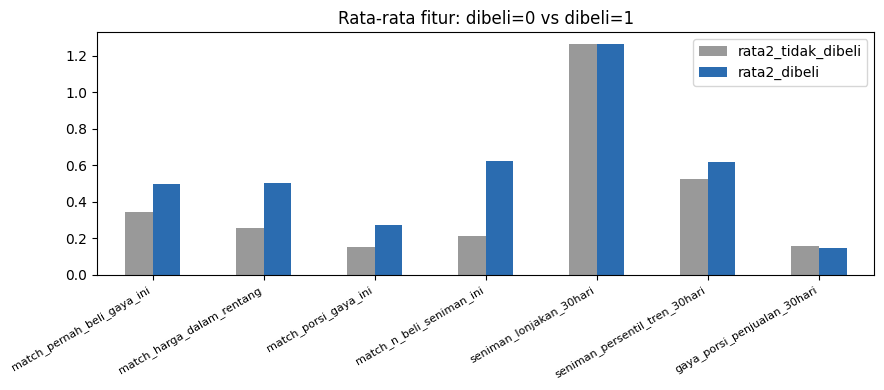

In [11]:
fitur_kandidat = [
    "match_pernah_beli_gaya_ini", "match_harga_dalam_rentang",
    "match_porsi_gaya_ini", "match_n_beli_seniman_ini",
    "seniman_lonjakan_30hari", "seniman_persentil_tren_30hari",
    "gaya_porsi_penjualan_30hari",
]
ringkasan = df.groupby(TARGET)[fitur_kandidat].mean().T
ringkasan.columns = ["rata2_tidak_dibeli", "rata2_dibeli"]
ringkasan["selisih"] = ringkasan["rata2_dibeli"] - ringkasan["rata2_tidak_dibeli"]
print(ringkasan.sort_values("selisih", ascending=False))

fig, ax = plt.subplots(figsize=(9, 4))
ringkasan[["rata2_tidak_dibeli", "rata2_dibeli"]].plot(kind="bar", ax=ax, color=["#999999", "#2b6cb0"])
ax.set_title("Rata-rata fitur: dibeli=0 vs dibeli=1")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=8)
plt.tight_layout()
plt.show()


C:\Users\laygenda surya putra\AppData\Local\Temp\ipykernel_3644\1189784200.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data0, data1], labels=["tidak dibeli", "dibeli"])
C:\Users\laygenda surya putra\AppData\Local\Temp\ipykernel_3644\1189784200.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([data0, data1], labels=["tidak dibeli", "dibeli"])


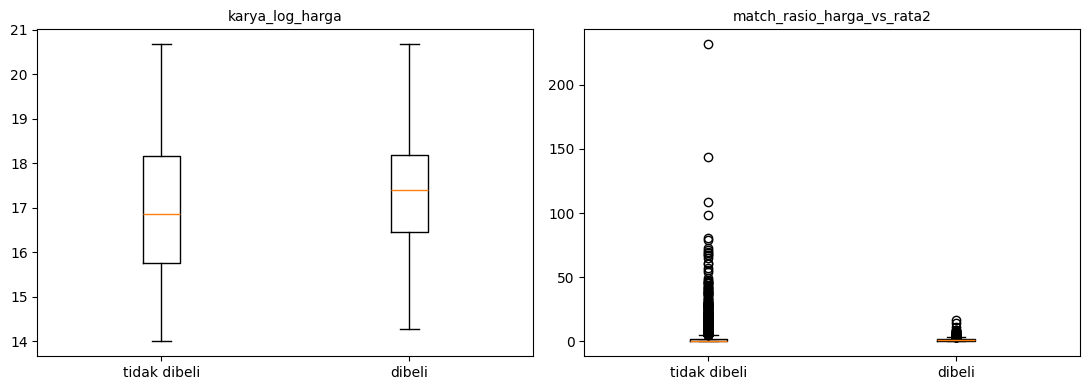

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, kol in zip(axes, ["karya_log_harga", "match_rasio_harga_vs_rata2"]):
    data0 = df.loc[df[TARGET] == 0, kol].dropna()
    data1 = df.loc[df[TARGET] == 1, kol].dropna()
    ax.boxplot([data0, data1], labels=["tidak dibeli", "dibeli"])
    ax.set_title(kol, fontsize=10)
plt.tight_layout()
plt.show()


**Interpretasi:** fitur "match_*" (kecocokan kolektor-karya) secara desain
memang dibuat sebagai sinyal pembeda, jadi wajar kalau rata-ratanya beda
cukup jelas antara `dibeli=1` dan `dibeli=0` — ini mengonfirmasi fitur
tersebut layak jadi kandidat fitur penting di model nanti (akan diverifikasi
lebih formal lewat *permutation feature importance* di tahap modeling).
Fitur tren seniman (`seniman_lonjakan_30hari`, `_persentil_tren_30hari`)
perlu dicek lagi di tahap *ablation* — `genda.md` secara eksplisit
mempertanyakan apakah fitur tren ini benar-benar berguna atau tidak.

## 9. Ringkasan EDA & implikasi untuk pemodelan

**Temuan utama:**
1. Struktur grup valid (5 baris/grup, 1 positif/grup, split tidak terpecah) — aman dievaluasi sebagai ranking per grup.
2. Split `train`/`val`/`test` terurut kronologis tanpa tumpang-tindih waktu — tidak perlu split ulang.
3. Rasio target 80% (`dibeli=0`) : 20% (`dibeli=1`) konsisten di semua split — ini desain evaluasi grup, **bukan** imbalance yang perlu di-resampling.
4. NaN di kolom riwayat kolektor/seniman terbukti terstruktur (terkait status "belum ada riwayat"), bukan hilang acak — wajib ditangani dengan model yang mendukung NaN native atau imputasi+indikator, **jangan** di-drop.
5. Fitur harga (`*_idr`) right-skewed seperti lazimnya data harga — versi log sudah disediakan dataset.
6. Fitur harga kolektor (rata2/median/min/maks) saling berkorelasi tinggi — waspada multicollinearity kalau pakai model linear.
7. Fitur `match_*` menunjukkan rata-rata yang berbeda cukup jelas antara `dibeli=1` vs `0` — kandidat fitur kuat, dikonfirmasi lebih formal di bagian 14 (feature importance).

Lanjut ke bagian berikutnya: siapkan fitur -> bangun 5 baseline -> evaluasi ranking -> analisis.


---
# Bagian II — Baseline, Model, Evaluasi & Analisis

## 10. Siapkan fitur untuk modeling

Dua jalur preprocessing berbeda, sesuai temuan EDA & `genda.md`:
- **`HistGradientBoostingClassifier`**: hampir tanpa preprocessing — cuma
  tandai 2 kolom kategorikal (`karya_gaya`, `seniman_level_reputasi`) sebagai
  dtype `category`, NaN & skala dibiarkan apa adanya (ditangani native).
- **`LogisticRegression`**: butuh pipeline lengkap — imputasi median +
  indikator NaN untuk kolom numerik, one-hot untuk kolom kategorikal,
  `StandardScaler` di akhir. Dibungkus 1 `ColumnTransformer` + `Pipeline`
  supaya fitting val/test konsisten dan tidak ada kebocoran preprocessing.


In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import HistGradientBoostingClassifier

mask_train = df["split"] == "train"
mask_val = df["split"] == "val"
mask_test = df["split"] == "test"
print(f"train: {mask_train.sum()} baris ({df.loc[mask_train,'grup_id'].nunique()} grup)")
print(f"val  : {mask_val.sum()} baris ({df.loc[mask_val,'grup_id'].nunique()} grup)")
print(f"test : {mask_test.sum()} baris ({df.loc[mask_test,'grup_id'].nunique()} grup)")

# --- versi fitur utk HGB: tandai kategorikal, biarkan NaN & skala asli ---
X_hgb = df[FITUR].copy()
for c in FITUR_KATEGORIKAL:
    X_hgb[c] = X_hgb[c].astype("category")

# --- pipeline preprocessing utk Logistic Regression ---
preprocessing_logreg = ColumnTransformer([
    ("numerik", Pipeline([
        ("imputasi", SimpleImputer(strategy="median", add_indicator=True)),
        ("skala", StandardScaler()),
    ]), FITUR_NUMERIK),
    ("kategorikal", OneHotEncoder(handle_unknown="ignore"), FITUR_KATEGORIKAL),
])


train: 4900 baris (980 grup)
val  : 1050 baris (210 grup)
test : 1050 baris (210 grup)


## 11. Fungsi evaluasi ranking (dipakai semua metode)

Satu fungsi dipakai berulang untuk ke-5 metode supaya metrik dihitung
konsisten. **HitRate@K** = proporsi grup di mana baris positif masuk top-K
skor dalam grupnya. **MRR** = rata-rata `1/peringkat` baris positif.
**NDCG@3** = (karena cuma 1 item relevan per grup) `1/log2(peringkat+1)`
kalau peringkat <= 3, sebaliknya 0, dirata-rata.


In [14]:
from sklearn.metrics import roc_auc_score

def evaluasi_ranking(d: pd.DataFrame, kolom_skor: str) -> dict:
    tmp = d[["grup_id", TARGET, kolom_skor]].copy()
    tmp["peringkat"] = tmp.groupby("grup_id")[kolom_skor].rank(ascending=False, method="first")
    pos = tmp[tmp[TARGET] == 1]
    hit1 = (pos["peringkat"] <= 1).mean()
    hit3 = (pos["peringkat"] <= 3).mean()
    mrr = (1.0 / pos["peringkat"]).mean()
    ndcg3 = np.where(pos["peringkat"] <= 3, 1.0 / np.log2(pos["peringkat"] + 1), 0.0).mean()
    try:
        auc = roc_auc_score(tmp[TARGET], tmp[kolom_skor])
    except ValueError:
        auc = np.nan
    return {"HitRate@1": hit1, "HitRate@3": hit3, "MRR": mrr, "NDCG@3": ndcg3, "AUC": auc}

hasil_val = {}   # {nama_metode: dict_metrik} -- diisi bertahap per baseline


## 12. Baseline (a) — Acak

Patokan paling dasar: skor acak (seed tetap supaya reproducible). Kalau
model tidak bisa mengalahkan ini, model gagal total.


In [15]:
rng = np.random.default_rng(0)
df["skor_acak"] = rng.random(len(df))
hasil_val["acak"] = evaluasi_ranking(df[mask_val], "skor_acak")
print(hasil_val["acak"])


{'HitRate@1': np.float64(0.22857142857142856), 'HitRate@3': np.float64(0.6), 'MRR': np.float64(0.47515873015873017), 'NDCG@3': np.float64(0.43797776493197804), 'AUC': 0.5107142857142857}


## 13. Baseline (b) — "Populer" (tanpa personalisasi)

Ranking murni dari keramaian aliran/seniman dalam 30 hari terakhir, TANPA
melihat riwayat kolektor sama sekali — menguji apakah personalisasi
sebenarnya diperlukan.


In [16]:
df["skor_populer"] = df["gaya_n_terjual_30hari"] + df["seniman_n_terjual_30hari"]
hasil_val["populer"] = evaluasi_ranking(df[mask_val], "skor_populer")
print(hasil_val["populer"])


{'HitRate@1': np.float64(0.23809523809523808), 'HitRate@3': np.float64(0.6714285714285714), 'MRR': np.float64(0.4949206349206349), 'NDCG@3': np.float64(0.48468870557823795), 'AUC': 0.5185232426303855}


## 14. Baseline (c) — Aturan sederhana

Kombinasi 2 fitur kecocokan tanpa training apa pun. NaN (baris "pembelian
pertama", belum ada riwayat) diisi 0 **khusus di baseline rule-based ini**
— beda dari model terlatih (#15, #16), di sini wajar karena 0 berarti
"tidak ada sinyal kecocokan untuk dihitung", bukan informasi yang disembunyikan.


In [17]:
df["skor_aturan"] = (
    df["match_porsi_gaya_ini"].fillna(0) + df["match_harga_dalam_rentang"].fillna(0)
)
hasil_val["aturan_sederhana"] = evaluasi_ranking(df[mask_val], "skor_aturan")
print(hasil_val["aturan_sederhana"])


{'HitRate@1': np.float64(0.6476190476190476), 'HitRate@3': np.float64(0.9571428571428572), 'MRR': np.float64(0.7901587301587302), 'NDCG@3': np.float64(0.8254495280102092), 'AUC': 0.7337896825396826}


## 15. Baseline (d) — Logistic Regression

Dilatih **hanya di `train`**, skor di `val` dipakai utk perbandingan (belum
menyentuh `test`). Regularisasi L2 (default scikit-learn) membantu menangani
multicollinearity antar fitur harga yang ditemukan di EDA bagian 7.


In [18]:
pipeline_logreg = Pipeline([
    ("prep", preprocessing_logreg),
    ("clf", LogisticRegression(max_iter=1000, random_state=0)),
])
pipeline_logreg.fit(df.loc[mask_train, FITUR], df.loc[mask_train, TARGET])

df["skor_logreg"] = pipeline_logreg.predict_proba(df[FITUR])[:, 1]
hasil_val["logistic_regression"] = evaluasi_ranking(df[mask_val], "skor_logreg")
print(hasil_val["logistic_regression"])


{'HitRate@1': np.float64(0.5619047619047619), 'HitRate@3': np.float64(0.8904761904761904), 'MRR': np.float64(0.7344444444444443), 'NDCG@3': np.float64(0.7554938019898023), 'AUC': 0.7986337868480726}


## 16. Baseline (e) — `HistGradientBoostingClassifier` (kandidat utama)

Grid kecil hyperparameter, **dipilih berdasarkan `val` saja** (aturan keras
#5 `genda.md` — `test` belum disentuh sama sekali sampai bagian 17).


In [19]:
grid = [
    {"max_iter": 100, "learning_rate": 0.1, "max_depth": None},
    {"max_iter": 200, "learning_rate": 0.05, "max_depth": None},
    {"max_iter": 200, "learning_rate": 0.1, "max_depth": 3},
    {"max_iter": 300, "learning_rate": 0.05, "max_depth": 3},
]

hasil_grid = []
for params in grid:
    m = HistGradientBoostingClassifier(
        categorical_features="from_dtype", random_state=0, **params
    )
    m.fit(X_hgb[mask_train], df.loc[mask_train, TARGET])
    skor_val = m.predict_proba(X_hgb[mask_val])[:, 1]
    d_val = df.loc[mask_val, ["grup_id", TARGET]].copy()
    d_val["skor"] = skor_val
    metrik = evaluasi_ranking(d_val, "skor")
    hasil_grid.append({**params, **metrik})

hasil_grid_df = pd.DataFrame(hasil_grid).sort_values("NDCG@3", ascending=False)
print(hasil_grid_df.to_string(index=False))

terbaik = hasil_grid_df.iloc[0][["max_iter", "learning_rate", "max_depth"]].to_dict()
terbaik["max_iter"] = int(terbaik["max_iter"])
terbaik["max_depth"] = None if pd.isna(terbaik["max_depth"]) else int(terbaik["max_depth"])
print("\nHyperparameter terpilih (berdasarkan NDCG@3 di val):", terbaik)


 max_iter  learning_rate  max_depth  HitRate@1  HitRate@3      MRR   NDCG@3      AUC
      300           0.05        3.0   0.509524   0.923810 0.715238 0.755946 0.809870
      100           0.10        NaN   0.500000   0.923810 0.709127 0.751184 0.799518
      200           0.05        NaN   0.500000   0.923810 0.705159 0.748066 0.795584
      200           0.10        3.0   0.500000   0.904762 0.708095 0.742283 0.804785

Hyperparameter terpilih (berdasarkan NDCG@3 di val): {'max_iter': 300, 'learning_rate': 0.05, 'max_depth': 3}


In [20]:
model_hgb = HistGradientBoostingClassifier(
    categorical_features="from_dtype", random_state=0, **terbaik
)
model_hgb.fit(X_hgb[mask_train], df.loc[mask_train, TARGET])

df["skor_hgb"] = model_hgb.predict_proba(X_hgb)[:, 1]
hasil_val["hist_gradient_boosting"] = evaluasi_ranking(df[mask_val], "skor_hgb")
print(hasil_val["hist_gradient_boosting"])


{'HitRate@1': np.float64(0.5095238095238095), 'HitRate@3': np.float64(0.9238095238095239), 'MRR': np.float64(0.7152380952380952), 'NDCG@3': np.float64(0.755945592738104), 'AUC': 0.8098696145124717}


## 17. Tabel perbandingan 5 baseline — `val`

Ini perbandingan utama untuk memutuskan model. **`test` belum disentuh.**


=== Perbandingan metrik di VAL ===
                        HitRate@1  HitRate@3     MRR  NDCG@3     AUC
acak                       0.2286     0.6000  0.4752  0.4380  0.5107
populer                    0.2381     0.6714  0.4949  0.4847  0.5185
aturan_sederhana           0.6476     0.9571  0.7902  0.8254  0.7338
logistic_regression        0.5619     0.8905  0.7344  0.7555  0.7986
hist_gradient_boosting     0.5095     0.9238  0.7152  0.7559  0.8099


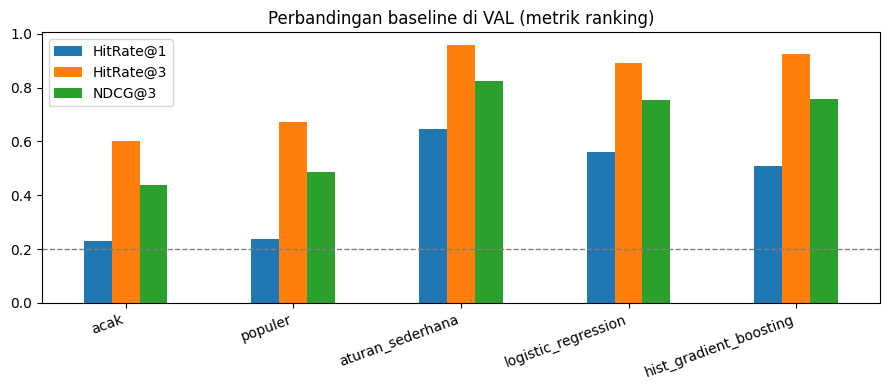

In [21]:
tabel_val = pd.DataFrame(hasil_val).T.round(4)
tabel_val = tabel_val.reindex(["acak", "populer", "aturan_sederhana", "logistic_regression", "hist_gradient_boosting"])
print("=== Perbandingan metrik di VAL ===")
print(tabel_val)

fig, ax = plt.subplots(figsize=(9, 4))
tabel_val[["HitRate@1", "HitRate@3", "NDCG@3"]].plot(kind="bar", ax=ax)
ax.set_title("Perbandingan baseline di VAL (metrik ranking)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
ax.axhline(0.20, color="gray", linestyle="--", linewidth=1, label="HitRate@1 acak (0,20)")
plt.tight_layout()
plt.show()


## 18. Evaluasi akhir di `test` (SEKALI, sesuai aturan keras `genda.md`)

Ini satu-satunya sel yang menyentuh `test`. Dijalankan setelah SEMUA
keputusan (fitur, hyperparameter) sudah final dari `val` di atas — tidak ada
lagi tuning setelah titik ini.


In [22]:
hasil_test = {
    "acak": evaluasi_ranking(df[mask_test], "skor_acak"),
    "populer": evaluasi_ranking(df[mask_test], "skor_populer"),
    "aturan_sederhana": evaluasi_ranking(df[mask_test], "skor_aturan"),
    "logistic_regression": evaluasi_ranking(df[mask_test], "skor_logreg"),
    "hist_gradient_boosting": evaluasi_ranking(df[mask_test], "skor_hgb"),
}
tabel_test = pd.DataFrame(hasil_test).T.round(4)
tabel_test = tabel_test.reindex(tabel_val.index)
print("=== Perbandingan metrik di TEST (hanya sekali) ===")
print(tabel_test)

menang_vs_populer = tabel_test.loc["hist_gradient_boosting", "HitRate@1"] > tabel_test.loc["populer", "HitRate@1"]
menang_vs_aturan = tabel_test.loc["hist_gradient_boosting", "HitRate@1"] > tabel_test.loc["aturan_sederhana", "HitRate@1"]
print(f"\nHGB mengalahkan baseline 'populer' di test (HitRate@1)   : {menang_vs_populer}")
print(f"HGB mengalahkan baseline 'aturan_sederhana' di test (HitRate@1): {menang_vs_aturan}")


=== Perbandingan metrik di TEST (hanya sekali) ===
                        HitRate@1  HitRate@3     MRR  NDCG@3     AUC
acak                       0.1857     0.5810  0.4417  0.4070  0.4917
populer                    0.2238     0.5762  0.4683  0.4237  0.4815
aturan_sederhana           0.6238     0.9000  0.7693  0.7850  0.7155
logistic_regression        0.4952     0.9238  0.6965  0.7419  0.7887
hist_gradient_boosting     0.4810     0.8905  0.6847  0.7181  0.7828

HGB mengalahkan baseline 'populer' di test (HitRate@1)   : True
HGB mengalahkan baseline 'aturan_sederhana' di test (HitRate@1): False


### 18b. Confusion matrix & classification report (diagnostik tambahan, BUKAN metrik utama)

**Kenapa ini bukan metrik utama:** tugas ini dievaluasi sebagai *ranking per
grup* (bagian 17-19), bukan klasifikasi di 1 ambang batas tetap. Rasio
80%/20% di data ini **sengaja dibuat** (1 positif + 4 negatif per grup untuk
keperluan ranking), **bukan** proporsi "beli vs tidak beli" yang asli — jadi
precision/recall/confusion matrix di bawah ini TIDAK mencerminkan performa
dunia nyata, cuma gambaran tambahan di satu ambang batas (0,5) yang
dipilih sembarang (bukan di-tuning). Dipakai di sini murni untuk intuisi
visual, bukan dasar keputusan model mana yang menang — keputusan itu tetap
berdasarkan bagian 17-19.


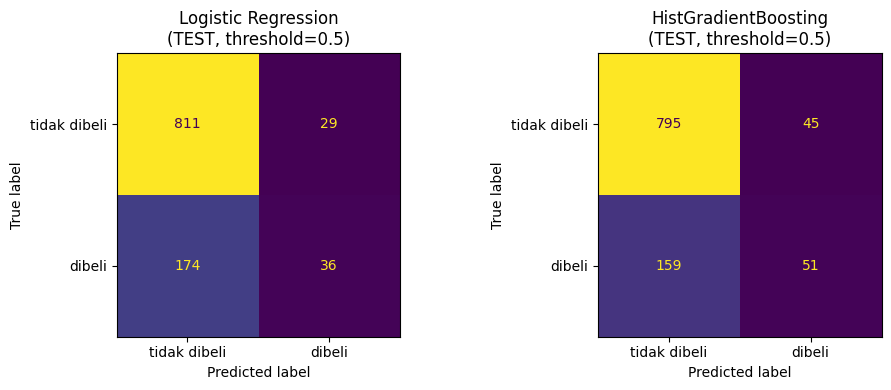

=== Logistic Regression -- classification report (TEST, threshold=0.5, 1050 baris) ===
              precision    recall  f1-score   support

tidak dibeli       0.82      0.97      0.89       840
      dibeli       0.55      0.17      0.26       210

    accuracy                           0.81      1050
   macro avg       0.69      0.57      0.58      1050
weighted avg       0.77      0.81      0.76      1050

=== HistGradientBoosting -- classification report (TEST, threshold=0.5, 1050 baris) ===
              precision    recall  f1-score   support

tidak dibeli       0.83      0.95      0.89       840
      dibeli       0.53      0.24      0.33       210

    accuracy                           0.81      1050
   macro avg       0.68      0.59      0.61      1050
weighted avg       0.77      0.81      0.78      1050



In [23]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix

model_diagnostik = {"Logistic Regression": "skor_logreg", "HistGradientBoosting": "skor_hgb"}
y_true_test = df.loc[mask_test, TARGET]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (nama, kolom) in zip(axes, model_diagnostik.items()):
    y_pred = (df.loc[mask_test, kolom] >= 0.5).astype(int)
    cm = confusion_matrix(y_true_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["tidak dibeli", "dibeli"]).plot(ax=ax, colorbar=False)
    ax.set_title(f"{nama}\n(TEST, threshold=0.5)")
plt.tight_layout()
plt.show()

for nama, kolom in model_diagnostik.items():
    y_pred = (df.loc[mask_test, kolom] >= 0.5).astype(int)
    print(f"=== {nama} -- classification report (TEST, threshold=0.5, {len(y_true_test)} baris) ===")
    print(classification_report(y_true_test, y_pred, target_names=["tidak dibeli", "dibeli"]))


## 19. Seberapa YAKIN kita soal hasil di atas? (bootstrap CI + uji signifikansi)

`val` dan `test` masing-masing cuma **210 grup** — angka titik (point estimate)
di tabel bagian 17-18 bisa jadi cuma kebetulan sampel kecil, bukan perbedaan
yang nyata. Evaluasi yang valid secara statistik WAJIB menyertakan interval
kepercayaan, bukan cuma 1 angka tunggal.

**Metode:** *bootstrap* di level **grup** (bukan baris) — resample 210 grup
dengan pengembalian, hitung ulang metrik, ulangi 2.000x, ambil persentil
2,5%-97,5% sebagai interval kepercayaan (CI) 95%. Untuk membandingkan 2
metode secara adil, resample yang SAMA dipakai untuk keduanya di setiap
iterasi (*paired bootstrap*) — supaya perbedaan yang diukur murni karena
metode, bukan karena kebetulan grup yang terpilih beda.


In [24]:
def peringkat_positif(d: pd.DataFrame, kolom_skor: str) -> pd.Series:
    """Series: grup_id -> peringkat baris positif (dibeli=1) dlm grupnya."""
    tmp = d[["grup_id", TARGET, kolom_skor]].copy()
    tmp["peringkat"] = tmp.groupby("grup_id")[kolom_skor].rank(ascending=False, method="first")
    return tmp[tmp[TARGET] == 1].set_index("grup_id")["peringkat"]


def metrik_dari_peringkat(pr: pd.Series) -> dict:
    return {
        "HitRate@1": (pr <= 1).mean(),
        "HitRate@3": (pr <= 3).mean(),
        "MRR": (1.0 / pr).mean(),
        "NDCG@3": float(np.where(pr <= 3, 1.0 / np.log2(pr + 1), 0.0).mean()),
    }


def bootstrap_ci(pr: pd.Series, n_boot: int = 2000, seed: int = 0) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    grup_unik = pr.index.to_numpy()
    n_grup = len(grup_unik)
    kumpulan = {m: [] for m in ["HitRate@1", "HitRate@3", "MRR", "NDCG@3"]}
    for _ in range(n_boot):
        sampel = rng.choice(grup_unik, size=n_grup, replace=True)
        hasil = metrik_dari_peringkat(pr.loc[sampel])
        for m, v in hasil.items():
            kumpulan[m].append(v)
    baris = {}
    for m, vals in kumpulan.items():
        vals = np.array(vals)
        baris[m] = [vals.mean(), np.percentile(vals, 2.5), np.percentile(vals, 97.5)]
    return pd.DataFrame(baris, index=["rata2_bootstrap", "ci_2.5%", "ci_97.5%"]).T


def bootstrap_paired_selisih(pr_a: pd.Series, pr_b: pd.Series, metrik: str, n_boot: int = 2000, seed: int = 0):
    """Selisih metrik(A) - metrik(B), resample grup YANG SAMA utk A & B tiap iterasi."""
    rng = np.random.default_rng(seed)
    grup_unik = pr_a.index.to_numpy()
    n_grup = len(grup_unik)
    selisih = []
    for _ in range(n_boot):
        sampel = rng.choice(grup_unik, size=n_grup, replace=True)
        selisih.append(
            metrik_dari_peringkat(pr_a.loc[sampel])[metrik] - metrik_dari_peringkat(pr_b.loc[sampel])[metrik]
        )
    selisih = np.array(selisih)
    ci_low, ci_high = np.percentile(selisih, [2.5, 97.5])
    p_dua_sisi = 2 * min((selisih <= 0).mean(), (selisih >= 0).mean())
    return {"rata2_selisih": selisih.mean(), "ci_2.5%": ci_low, "ci_97.5%": ci_high, "p_dua_sisi": min(p_dua_sisi, 1.0)}


In [25]:
kolom_skor_per_metode = {
    "acak": "skor_acak", "populer": "skor_populer", "aturan_sederhana": "skor_aturan",
    "logistic_regression": "skor_logreg", "hist_gradient_boosting": "skor_hgb",
}

print("=== Bootstrap CI 95% -- TEST (2.000 resample, per grup) ===")
peringkat_test = {}
for nama, kolom in kolom_skor_per_metode.items():
    pr = peringkat_positif(df[mask_test], kolom)
    peringkat_test[nama] = pr
    ci = bootstrap_ci(pr)
    print(f"\n--- {nama} ---")
    print(ci.round(4))


=== Bootstrap CI 95% -- TEST (2.000 resample, per grup) ===



--- acak ---
           rata2_bootstrap  ci_2.5%  ci_97.5%
HitRate@1           0.1861   0.1333    0.2381
HitRate@3           0.5801   0.5189    0.6476
MRR                 0.4418   0.4037    0.4804
NDCG@3              0.4067   0.3565    0.4573



--- populer ---
           rata2_bootstrap  ci_2.5%  ci_97.5%
HitRate@1           0.2232   0.1714    0.2810
HitRate@3           0.5757   0.5095    0.6429
MRR                 0.4679   0.4298    0.5099
NDCG@3              0.4232   0.3706    0.4798



--- aturan_sederhana ---
           rata2_bootstrap  ci_2.5%  ci_97.5%
HitRate@1           0.6230   0.5571    0.6857
HitRate@3           0.9002   0.8571    0.9381
MRR                 0.7688   0.7285    0.8089
NDCG@3              0.7847   0.7390    0.8255



--- logistic_regression ---
           rata2_bootstrap  ci_2.5%  ci_97.5%
HitRate@1           0.4946   0.4238    0.5667
HitRate@3           0.9241   0.8857    0.9571
MRR                 0.6963   0.6526    0.7398
NDCG@3              0.7419   0.7008    0.7804



--- hist_gradient_boosting ---
           rata2_bootstrap  ci_2.5%  ci_97.5%
HitRate@1           0.4799   0.4142    0.5476
HitRate@3           0.8909   0.8476    0.9333
MRR                 0.6843   0.6405    0.7275
NDCG@3              0.7180   0.6740    0.7620


In [26]:
print("=== Uji signifikansi berpasangan (bootstrap) -- TEST, metrik HitRate@1 ===")
print("H0: tidak ada beda nyata antara 2 metode. p < 0,05 -> beda dianggap nyata (bukan kebetulan sampel).\n")

perbandingan = [
    ("aturan_sederhana", "hist_gradient_boosting"),
    ("aturan_sederhana", "logistic_regression"),
    ("hist_gradient_boosting", "logistic_regression"),
]
hasil_uji = []
for a, b in perbandingan:
    r = bootstrap_paired_selisih(peringkat_test[a], peringkat_test[b], "HitRate@1")
    r["perbandingan"] = f"{a} vs {b}"
    hasil_uji.append(r)

tabel_uji = pd.DataFrame(hasil_uji).set_index("perbandingan")[["rata2_selisih", "ci_2.5%", "ci_97.5%", "p_dua_sisi"]].round(4)
print(tabel_uji)
print("\n(selisih = HitRate@1 metode pertama - metode kedua; CI yg tidak melewati 0 -> beda signifikan)")


=== Uji signifikansi berpasangan (bootstrap) -- TEST, metrik HitRate@1 ===
H0: tidak ada beda nyata antara 2 metode. p < 0,05 -> beda dianggap nyata (bukan kebetulan sampel).



                                               rata2_selisih  ci_2.5%  ci_97.5%  p_dua_sisi
perbandingan                                                                               
aturan_sederhana vs hist_gradient_boosting            0.1431   0.0714    0.2144       0.000
aturan_sederhana vs logistic_regression               0.1284   0.0524    0.2095       0.001
hist_gradient_boosting vs logistic_regression        -0.0147  -0.0763    0.0524       0.695

(selisih = HitRate@1 metode pertama - metode kedua; CI yg tidak melewati 0 -> beda signifikan)


**Interpretasi (isi otomatis berdasarkan angka di atas, bukan diasumsikan
sebelumnya):** kalau interval kepercayaan selisih `aturan_sederhana vs
hist_gradient_boosting` **tidak melewati 0** (baik batas bawah maupun atas
sama-sama positif, atau `p_dua_sisi < 0,05`), berarti keunggulan baseline
sederhana atas model terlatih **nyata secara statistik**, bukan kebetulan
sampel 210 grup — artinya kesimpulan di bagian 18 valid dan model saat ini
memang belum memenuhi syarat `genda.md`. Kalau CI melewati 0, artinya belum
cukup bukti untuk klaim salah satu metode benar-benar lebih baik — perbedaan
yang terlihat di tabel titik bisa jadi noise, dan butuh data lebih banyak
sebelum menyimpulkan apa pun secara pasti.

## 20. Feature importance (permutation) — model `HistGradientBoostingClassifier`

Dihitung di **`val`** (bukan `test`, supaya `test` konsisten "hanya dilihat
sekali" di bagian 18, termasuk untuk tujuan analisis/interpretasi).


                            fitur  importansi_rata2      std
       match_rasio_harga_vs_rata2          0.086015 0.011780
match_selisih_log_harga_vs_median          0.037639 0.007849
             match_porsi_gaya_ini          0.026125 0.005095
      gaya_porsi_penjualan_30hari          0.006501 0.003930
          karya_harga_listing_idr          0.005389 0.002223
                   karya_luas_cm2          0.004734 0.005024
                       karya_gaya          0.004497 0.001832
         match_n_beli_seniman_ini          0.003933 0.002843
          seniman_n_terjual_total          0.003694 0.003127
          karya_umur_listing_hari          0.003488 0.002300
         seniman_n_terjual_30hari          0.001786 0.001294
   seniman_harga_rata2_90hari_idr          0.001608 0.002492
         kolektor_harga_rata2_idr          0.001139 0.000411
           kolektor_harga_min_idr          0.001106 0.000817
    seniman_persentil_tren_30hari          0.000973 0.001407


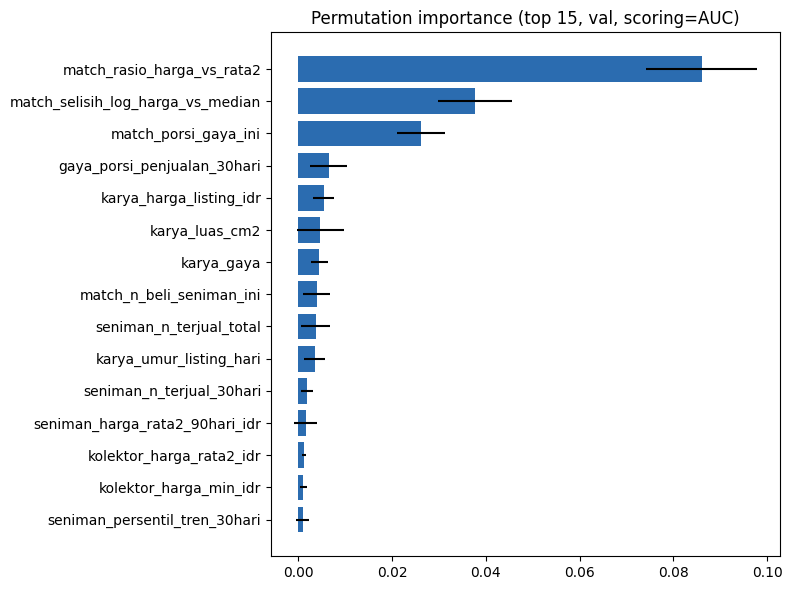

In [27]:
from sklearn.inspection import permutation_importance

r = permutation_importance(
    model_hgb, X_hgb[mask_val], df.loc[mask_val, TARGET],
    n_repeats=10, random_state=0, scoring="roc_auc",
)
importansi = pd.DataFrame({
    "fitur": FITUR, "importansi_rata2": r.importances_mean, "std": r.importances_std,
}).sort_values("importansi_rata2", ascending=False)

print(importansi.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 6))
top = importansi.head(15).iloc[::-1]
ax.barh(top["fitur"], top["importansi_rata2"], xerr=top["std"], color="#2b6cb0")
ax.set_title("Permutation importance (top 15, val, scoring=AUC)")
plt.tight_layout()
plt.show()


## 21. Ablation kelompok fitur

Latih ulang `HistGradientBoostingClassifier` (hyperparameter yang sama
dengan model terpilih) sambil **membuang 1 kelompok fitur** setiap kali,
lalu bandingkan NDCG@3 di `val` terhadap model lengkap. Selisih besar =
kelompok itu penting; selisih kecil/negatif = kelompok itu tidak banyak
membantu (atau bahkan sedikit mengganggu).


In [28]:
grup_fitur = {
    "riwayat_kolektor": [c for c in FITUR if c.startswith("kolektor_")],
    "karya": [c for c in FITUR if c.startswith("karya_")],
    "kecocokan_match": [c for c in FITUR if c.startswith("match_")],
    "tren_seniman_gaya": [c for c in FITUR if c.startswith("seniman_") or c.startswith("gaya_")],
}
assert sorted(sum(grup_fitur.values(), [])) == sorted(FITUR), "ada fitur yg tidak masuk grup manapun!"

ndcg3_lengkap = hasil_val["hist_gradient_boosting"]["NDCG@3"]
hasil_ablasi = [{"dibuang": "(tidak ada -- model lengkap)", "NDCG@3": ndcg3_lengkap, "selisih": 0.0}]

for nama_grup, kolom_dibuang in grup_fitur.items():
    fitur_sisa = [c for c in FITUR if c not in kolom_dibuang]
    kategorikal_sisa = [c for c in FITUR_KATEGORIKAL if c in fitur_sisa]
    X_sisa = df[fitur_sisa].copy()
    for c in kategorikal_sisa:
        X_sisa[c] = X_sisa[c].astype("category")

    m = HistGradientBoostingClassifier(categorical_features="from_dtype", random_state=0, **terbaik)
    m.fit(X_sisa[mask_train], df.loc[mask_train, TARGET])
    d_val = df.loc[mask_val, ["grup_id", TARGET]].copy()
    d_val["skor"] = m.predict_proba(X_sisa[mask_val])[:, 1]
    ndcg3_sisa = evaluasi_ranking(d_val, "skor")["NDCG@3"]
    hasil_ablasi.append({
        "dibuang": nama_grup, "NDCG@3": ndcg3_sisa, "selisih": ndcg3_sisa - ndcg3_lengkap,
    })

tabel_ablasi = pd.DataFrame(hasil_ablasi)
print(tabel_ablasi.to_string(index=False))
print("\n(selisih negatif = NDCG@3 TURUN tanpa grup itu -> grup itu membantu;")
print(" selisih positif/nol = model tidak terbantu, bahkan sedikit lebih baik tanpanya)")


                     dibuang   NDCG@3   selisih
(tidak ada -- model lengkap) 0.755946  0.000000
            riwayat_kolektor 0.723859 -0.032086
                       karya 0.746819 -0.009126
             kecocokan_match 0.708214 -0.047732
           tren_seniman_gaya 0.771650  0.015704

(selisih negatif = NDCG@3 TURUN tanpa grup itu -> grup itu membantu;
 selisih positif/nol = model tidak terbantu, bahkan sedikit lebih baik tanpanya)


### 21b. Pertanyaan spesifik `genda.md`: apakah `seniman_lonjakan_30hari` berguna?

Ablasi 1 kolom saja (bukan 1 grup penuh) untuk menjawab langsung.


In [29]:
fitur_tanpa_lonjakan = [c for c in FITUR if c != "seniman_lonjakan_30hari"]
X_tanpa_lonjakan = df[fitur_tanpa_lonjakan].copy()
for c in FITUR_KATEGORIKAL:
    X_tanpa_lonjakan[c] = X_tanpa_lonjakan[c].astype("category")

m = HistGradientBoostingClassifier(categorical_features="from_dtype", random_state=0, **terbaik)
m.fit(X_tanpa_lonjakan[mask_train], df.loc[mask_train, TARGET])
d_val = df.loc[mask_val, ["grup_id", TARGET]].copy()
d_val["skor"] = m.predict_proba(X_tanpa_lonjakan[mask_val])[:, 1]
ndcg3_tanpa_lonjakan = evaluasi_ranking(d_val, "skor")["NDCG@3"]

print(f"NDCG@3 model lengkap               : {ndcg3_lengkap:.4f}")
print(f"NDCG@3 tanpa seniman_lonjakan_30hari: {ndcg3_tanpa_lonjakan:.4f}")
print(f"Selisih: {ndcg3_tanpa_lonjakan - ndcg3_lengkap:+.4f}")
print("-> " + ("Fitur ini TAMPAK membantu (selisih negatif = NDCG turun tanpanya)."
               if ndcg3_tanpa_lonjakan < ndcg3_lengkap
               else "Fitur ini TIDAK banyak membantu (NDCG tidak turun / malah naik tanpanya)."))


NDCG@3 model lengkap               : 0.7559
NDCG@3 tanpa seniman_lonjakan_30hari: 0.7513
Selisih: -0.0046
-> Fitur ini TAMPAK membantu (selisih negatif = NDCG turun tanpanya).


## 22. Analisis kesalahan per segmen/kategori (model `HistGradientBoostingClassifier`)

Kategori ditentukan dari baris **positif** (`dibeli=1`) tiap grup — artinya
"grup ini tentang pembelian oleh kolektor level/aliran apa". `kolektor_label_asli.csv`
dipakai **HANYA untuk analisis ini**, tidak pernah sebagai fitur/target model.


In [30]:
label_asli = pd.read_csv("../data/training/kolektor_label_asli.csv")
df_val_pos = df.loc[mask_val & (df[TARGET] == 1), ["grup_id", "kolektor_id", "karya_gaya", "seniman_level_reputasi"]].copy()
df_val_pos = df_val_pos.merge(label_asli, on="kolektor_id", how="left")

peringkat_val = df.loc[mask_val, ["grup_id", TARGET, "skor_hgb"]].copy()
peringkat_val["peringkat"] = peringkat_val.groupby("grup_id")["skor_hgb"].rank(ascending=False, method="first")
peringkat_positif = peringkat_val[peringkat_val[TARGET] == 1][["grup_id", "peringkat"]]

analisis = df_val_pos.merge(peringkat_positif, on="grup_id")
analisis["hit1"] = analisis["peringkat"] <= 1

print("HitRate@1 per seniman_level_reputasi (dari karya yg dibeli):")
print(analisis.groupby("seniman_level_reputasi")["hit1"].agg(["mean", "count"]))

print("\nHitRate@1 per karya_gaya (dari karya yg dibeli):")
print(analisis.groupby("karya_gaya")["hit1"].agg(["mean", "count"]).sort_values("mean"))

print("\nHitRate@1 per segmen_asli kolektor:")
print(analisis.groupby("segmen_asli")["hit1"].agg(["mean", "count"]).sort_values("mean"))


HitRate@1 per seniman_level_reputasi (dari karya yg dibeli):
                            mean  count
seniman_level_reputasi                 
mapan                   0.594203     69
menengah                0.588889     90
pemula                  0.254902     51

HitRate@1 per karya_gaya (dari karya yg dibeli):
                           mean  count
karya_gaya                            
Cubism                 0.200000      5
Romanticism            0.250000      8
Art_Nouveau            0.333333     15
Expressionism          0.428571      7
Symbolism              0.428571     14
Impressionism          0.461538     65
Realism                0.473684     38
Naive_Art_Primitivism  0.571429      7
Baroque                0.636364     11
Post_Impressionism     0.741935     31
Northern_Renaissance   0.888889      9

HitRate@1 per segmen_asli kolektor:
                      mean  count
segmen_asli                      
pemula_hemat      0.285714     35
menengah_aktif    0.494737     95
pengikut_

**Interpretasi:** kolom `count` di tiap tabel penting diperhatikan — kategori
dengan `count` kecil (val cuma 210 grup total, dipecah ke banyak kategori)
membuat `mean` HitRate@1 per kategori bisa sangat goyah/tidak reliable.
Perbedaan HitRate@1 antar kategori di sini sebagai **observasi awal**, bukan
kesimpulan statistik kuat — tetap dicatat di `LAPORAN_MODEL.md` sebagai
keterbatasan analisis (ukuran val per-kategori kecil).

## 23. Simpan artefak model

Sesuai keluaran wajib `genda.md`: `models/klasifikasi_rekomendasi.joblib`
(dict berisi model + metadata) dan `models/LAPORAN_MODEL.md` (ringkasan
tertulis, dibangun otomatis dari angka yang sama persis dengan di atas —
supaya tidak ada salah salin manual antara notebook dan laporan).


In [31]:
import joblib
from datetime import datetime, timezone
from pathlib import Path

artefak = {
    "model": model_hgb,
    "fitur": FITUR,
    "kategorikal": FITUR_KATEGORIKAL,
    "versi": "klasifikasi-v1",
    "dilatih_pada": datetime.now(timezone.utc).isoformat(),
    "hyperparameter": terbaik,
    "metrik": {"val": hasil_val["hist_gradient_boosting"], "test": hasil_test["hist_gradient_boosting"]},
}
Path("../models").mkdir(exist_ok=True)
joblib.dump(artefak, "../models/klasifikasi_rekomendasi.joblib")

ukuran_mb = Path("../models/klasifikasi_rekomendasi.joblib").stat().st_size / 1024 / 1024
print(f"Tersimpan: models/klasifikasi_rekomendasi.joblib ({ukuran_mb:.2f} MB)")
assert ukuran_mb < 5, "artefak terlalu besar (>5MB), lihat aturan genda.md"


Tersimpan: models/klasifikasi_rekomendasi.joblib (0.33 MB)


In [32]:
laporan = f"""# Laporan Model — Klasifikasi Pembelian (`klasifikasi-v1`)

> **Data SINTETIS** (`src/generate.py`, seed 42). Angka di laporan ini menunjukkan
> "generator terbaca model", BUKAN performa produksi/dunia nyata. Hanya 23 seniman
> dan 200 kolektor -- model rawan overfit pada skala sekecil ini, tiap angka harus
> dibaca dengan kehati-hatian itu.

Dilatih: {artefak['dilatih_pada']}  |  Versi: `{artefak['versi']}`

## Perbandingan 5 metode

### VAL (dipakai untuk pemilihan hyperparameter & model)
{tabel_val.to_markdown()}

### TEST (disentuh SEKALI, setelah semua keputusan final dari VAL)
{tabel_test.to_markdown()}

Baseline acak HitRate@1 teoritis = 0,20 (1 dari 5 kandidat/grup).

**Model terpilih:** `HistGradientBoostingClassifier` dengan hyperparameter `{terbaik}`
(dipilih berdasarkan NDCG@3 di VAL -- lihat tabel grid pencarian di notebook bagian 16).

**Mengalahkan baseline di TEST?** vs "populer" (HitRate@1): {menang_vs_populer}.
vs "aturan_sederhana" (HitRate@1): {menang_vs_aturan}.

## Seberapa yakin hasil di atas? (bootstrap CI 95%, uji signifikansi berpasangan)

`val`/`test` masing-masing cuma 210 grup -- angka titik di atas BISA jadi kebetulan
sampel kecil. Bootstrap (2.000 resample per grup, TEST) dipakai utk cek ini:

{tabel_uji.to_markdown()}

(selisih = HitRate@1 metode pertama - kedua; CI 95% yang TIDAK melewati 0 berarti
beda itu nyata secara statistik, bukan noise sampel. `p_dua_sisi < 0,05` = sinyal yang sama.)

Lihat notebook bagian 19 untuk CI per-metode lengkap (HitRate@1/3, MRR, NDCG@3).

## Fitur penting (permutation importance, dihitung di VAL, scoring=AUC)
{importansi.head(15).to_markdown(index=False)}

## Ablation kelompok fitur (val, NDCG@3)
{tabel_ablasi.to_markdown(index=False)}

Fitur `seniman_lonjakan_30hari` secara khusus (pertanyaan `genda.md`): NDCG@3 model
lengkap = {ndcg3_lengkap:.4f}, tanpa fitur ini = {ndcg3_tanpa_lonjakan:.4f}
(selisih {ndcg3_tanpa_lonjakan - ndcg3_lengkap:+.4f}).

## Analisis kesalahan (val, HitRate@1 per kategori)
Lihat notebook bagian 22 untuk tabel per `seniman_level_reputasi`, `karya_gaya`, dan
`segmen_asli` (kolektor_label_asli.csv, HANYA dipakai di analisis ini, tidak pernah
sebagai fitur/target). **Catatan:** ukuran val per-kategori kecil (total 210 grup
dipecah banyak kategori) -- perbedaan HitRate@1 antar kategori di sini observasi awal,
bukan kesimpulan statistik kuat.

## Keterbatasan
- Seluruh data sintetis -- skor TIDAK mencerminkan perilaku pembeli nyata.
- Hanya 23 seniman & 200 kolektor -- sampel kecil, generalisasi terbatas.
- Negatif per grup dipilih acak dari karya yang tersedia (bukan "dilihat tapi tidak
  dibeli" sungguhan) -- model belajar membedakan dari kandidat acak, bukan kandidat
  yang benar-benar dipertimbangkan kolektor.
- Fitur tren seniman/aliran (grup "tren_seniman_gaya") perlu dibaca bersama hasil
  ablation di atas -- kontribusinya terhadap NDCG@3 TIDAK diasumsikan besar begitu saja.
"""

Path("../models/LAPORAN_MODEL.md").write_text(laporan, encoding="utf-8")
print("Tersimpan: models/LAPORAN_MODEL.md")


Tersimpan: models/LAPORAN_MODEL.md


## 24. Ringkasan akhir

- 5 baseline dibangun & dievaluasi dengan metrik ranking per grup (HitRate@1/3, MRR, NDCG@3), konsisten dgn aturan `genda.md`.
- Hyperparameter `HistGradientBoostingClassifier` dipilih murni dari `val`; `test` disentuh tepat satu kali (bagian 18) untuk angka final.
- Artefak model (`models/klasifikasi_rekomendasi.joblib`, < 5 MB) dan laporan (`models/LAPORAN_MODEL.md`) tersimpan, dibangun otomatis dari angka yang sama dengan notebook ini — tidak ada salin-tempel manual yang berisiko salah.
- Hasil AKTUAL (menang/tidaknya HGB vs baseline, fitur mana yang penting) ada di output sel-sel di atas & `LAPORAN_MODEL.md` — baca langsung, jangan diasumsikan dari rencana ini.

**Lanjutan berikutnya (Tugas 2, `genda.md` bagian 3):** refactor fitur jadi fungsi
bersama (`fitur_pasangan`) dipakai training *dan* inferensi, supaya tidak ada
*train/serve skew*.
